In [34]:
import matplotlib.pyplot as plt
import numpy as np
import random
import networkx as nx
import scipy

from fivetwo.deck import Deck
from fivetwo.shuffler import Shuffler
from fivetwo.stats import Statistics

### Importing the Deck

#### (Laptop) MtG Deck

In [2]:
# import sys
# sys.path.insert(0, r"C:\Users\colli\OneDrive\Documents\Code\git\card_converter\src")

# from deck_conversion import Converter

# premade_deck = Converter(file_name = r"C:\Users\colli\OneDrive\Documents\Code\git\card_converter\decklists\makin'_copies.txt")
# premade_deck = premade_deck.converted
# deck = Deck(premade_deck)

#### (Desktop) Deck of Random Values

In [3]:
deck = np.array([random.randint(1, 8) for _ in range(99)])
# deck = np.array([random.choice([1, 4]) for _ in range(99)])

### Operator Method

In [4]:
def organized_pile_shuffle(number_of_cards: int, number_of_piles: int):
    """
    Creates the operator for the 'Organized Pile Shuffle' method of shuffling a deck.
    This method assumes that each card of the deck is laid out into 'number_of_piles'
    number of piles sequentially and then sequentially organized back into a deck.
    ---
    Parameters:
        number_of_cards, int: The length of the decklist.
        number_of_piles, int: How many piles the cards will be distributed among.
    """

    cards_per_pile = number_of_cards // number_of_piles
    operator = np.zeros((number_of_cards, number_of_cards))

    cycle = 1
    for card_number in range(number_of_cards):
        pile_number = (card_number % number_of_piles) + 1
        operator[card_number, cards_per_pile * pile_number - cycle] = 1
        if card_number == 0:
            continue

        check = card_number / (number_of_piles - 1)
        if check - int(check) == 0.0:
            cycle += 1

    return operator

#### Applying the shuffle operator to change the state of the deck

In [5]:
initial_state = deck#.cards # Uncomment the '.cards' for running on the laptop.
operator = operator = organized_pile_shuffle(len(deck), 9)
new_state = np.array(np.matmul(operator, initial_state), dtype=int)

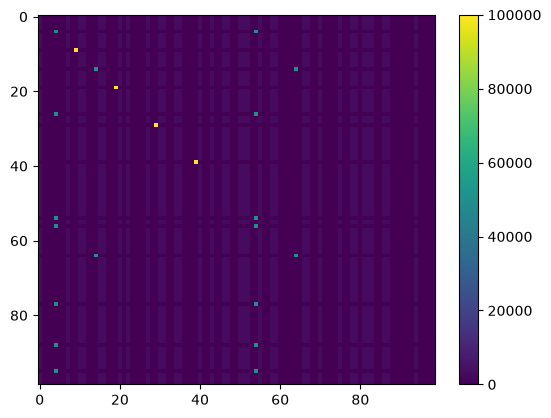

In [6]:
cards_per_pile = len(deck) // 9
plt_operator = np.identity(len(deck))
operator_heatmap = np.zeros_like(operator)
for i in range(100000):
    plt_operator = np.dot(plt_operator, operator)
    operator_heatmap += plt_operator
plt.imshow(operator_heatmap, aspect='auto')
plt.colorbar()

#### Visualizing the state transformation

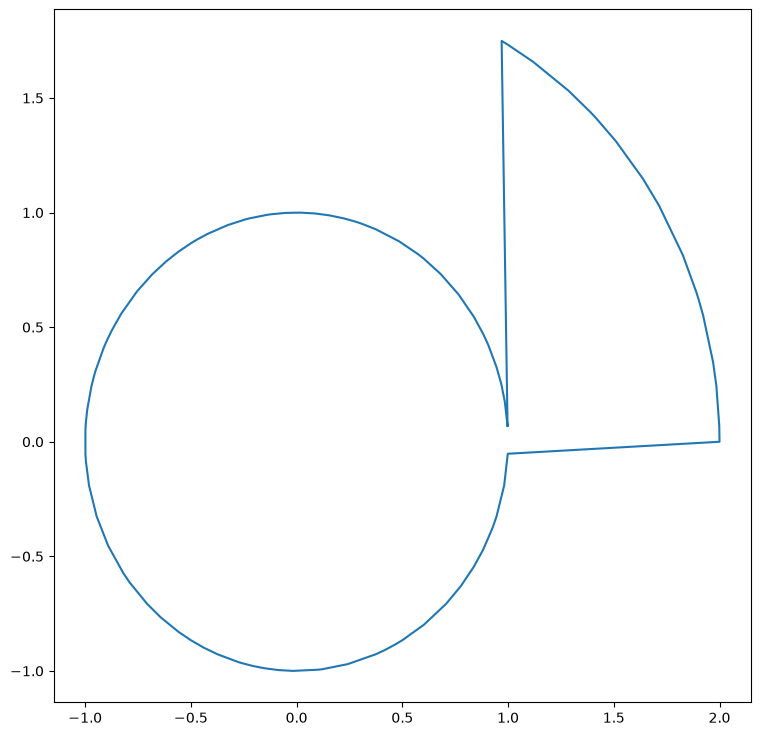

In [7]:
def polygonal_representation(cards: list):
    """
    Returns a list of points that represent the polygonal shape of the state of cards.
    """

    theta = 0                             
    r = 1
    x_points, y_points = [], []
    for card in cards:
        theta += card * (np.pi / 180)
        if theta >= 2 * np.pi:
            r += 1
            theta = 0
        x_points.append(r * np.cos(theta))
        y_points.append(r * np.sin(theta))

    # Adding the first point to close the set.
    x_points.append(x_points[0])
    y_points.append(y_points[0])

    return x_points, y_points

x, y = polygonal_representation(new_state)
plt.figure(figsize=(9,9))
# plt.plot(np.diff(x), np.diff(y), '.')
plt.plot(x, y)
plt.show()

{np.int64(4): Text(1.0, 0.0, '4'),
 np.int64(6): Text(0.7071067811865476, 0.7071067811865476, '6'),
 np.int64(1): Text(6.123233995736766e-17, 1.0, '1'),
 np.int64(3): Text(-0.7071067811865475, 0.7071067811865476, '3'),
 np.int64(5): Text(-1.0, 1.2246467991473532e-16, '5'),
 np.int64(7): Text(-0.7071067811865477, -0.7071067811865475, '7'),
 np.int64(2): Text(-1.8369701987210297e-16, -1.0, '2'),
 np.int64(8): Text(0.7071067811865474, -0.7071067811865477, '8')}

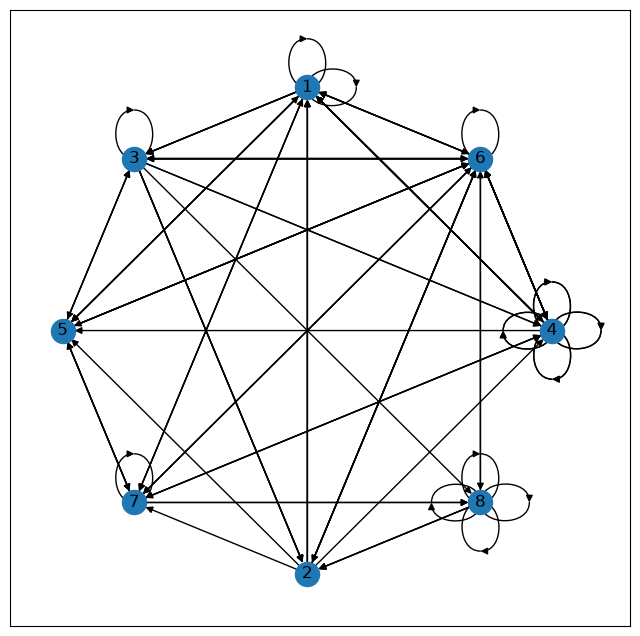

In [60]:
node_connections = list(zip(new_state, np.roll(new_state, -1)))[:-1] # Removing the last because the pairings are not cyclic.
directed_graph = nx.MultiDiGraph(node_connections)
nodes = directed_graph.nodes()
base_theta = 2 * np.pi / len(nodes)
positions = {node: (np.cos(i * base_theta), np.sin(i * base_theta)) for (i, node) in enumerate(nodes)}

plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(directed_graph, positions)
nx.draw_networkx_edges(directed_graph, positions)
nx.draw_networkx_labels(directed_graph, positions)
# nx.draw(
#     shell_layout,
#     node_size=500
# )

#### Visualizing In (cards that connect to) and Out (cards connected to) Edges

In [67]:
adjacency = directed_graph.adj
adjacency_matrix = np.zeros((len(nodes), len(nodes)))
for node, edges in adjacency.items():
    print(node)
    for edge in edges.keys():
        print(" ",edge)
    print("\n")

4
  6
  1
  4
  5
  7


6
  4
  3
  1
  7
  2
  8
  6
  5


1
  4
  1
  6
  3
  5
  7


3
  5
  4
  2
  6
  3
  8


5
  7
  1
  6
  3


7
  7
  6
  4
  5
  1
  8


2
  4
  6
  1
  7
  5


8
  8
  2
  6


